In [16]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
matches=pd.read_csv("matches.csv")
deliveries=pd.read_csv("deliveries.csv")
print(matches.head(5))
print("\n" + "-"*80 + "\n")
print(deliveries.head(5))

   id  season team1 team2 toss_winner toss_decision winner      venue
0   1    2020    MI   CSK         CSK         field    CSK      Dubai
1   2    2020   RCB   SRH         SRH           bat    RCB      Dubai
2   3    2020   KKR    MI          MI         field     MI  Abu Dhabi
3   4    2021   CSK   RCB         CSK           bat    CSK    Chennai
4   5    2021    MI   SRH          MI         field     MI     Mumbai

--------------------------------------------------------------------------------

   match_id  inning  over  ball   batter  bowler  total_runs dismissal_kind
0         1       1     1     1    Rohit  Chahar           1            NaN
1         1       1     1     2    Rohit  Chahar           4            NaN
2         1       1     1     3    Rohit  Chahar           0         caught
3         1       1     2     1  Pollard  Jadeja           6            NaN
4         1       1     2     2  Pollard  Jadeja           2            NaN


In [31]:
print("Total Numbers Of Matches = ",len(matches))
print("Total Number Of Deliveries =",len(deliveries))
print(matches.columns)
print(deliveries.columns)

Total Numbers Of Matches =  10
Total Number Of Deliveries = 21
Index(['id', 'season', 'team1', 'team2', 'toss_winner', 'toss_decision',
       'winner', 'venue'],
      dtype='object')
Index(['match_id', 'inning', 'over', 'ball', 'batter', 'bowler', 'total_runs',
       'dismissal_kind'],
      dtype='object')


In [38]:
win_count=matches['winner'].value_counts()
print("Team With Most Wins=",win_count.idxmax(),"With",win_count.max(),"Number of wins")

Team With Most Wins= RCB With 3 Number of wins:


In [60]:
bat_win = len(matches[(matches["toss_decision"]=="bat") & (matches["winner"]==matches["toss_winner"])])
field_win = len(matches[(matches["toss_decision"]=="field") & (matches["winner"]==matches["toss_winner"])])
print("Bat & Win:", bat_win)
print("Field & Win:", field_win)

Bat & Win: 2
Field & Win: 6


In [79]:
runs=deliveries.groupby("batter")["total_runs"].sum()
print("scored the most runs :-",runs.idxmax(),"Runs Scored=",runs.max())
wickets=deliveries[(deliveries["dismissal_kind"]=="caught") | (deliveries["dismissal_kind"]=="bowled")]
bowler_wickets = wickets.groupby("bowler")["dismissal_kind"].count()
print("Most Wickets Taken By :-", bowler_wickets.idxmax(),"Number Of Wickets Taken= ",bowler_wickets.max())

scored the most runs :- Kohli Runs Scored= 14
Most Wickets Taken By :- Bumrah Number Of Wickets Taken=  1


In [74]:
wickets

,match_id,inning,over,ball,batter,bowler,total_runs,dismissal_kind
2,1,1,1,3,Rohit,Chahar,0,caught
8,2,1,2,1,Maxwell,Rashid,2,caught
9,3,1,1,1,Iyer,Bumrah,0,bowled


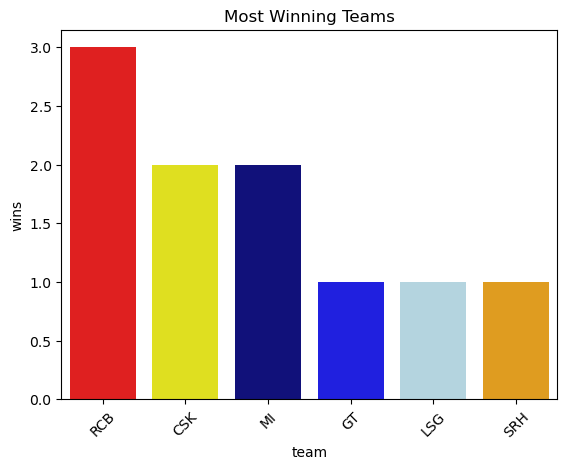

In [92]:
win_count = matches['winner'].value_counts().reset_index()
win_count.columns = ['team', 'wins']
color=["Red","Yellow","Darkblue","blue","lightblue","orange"]
sns.barplot(x='team', y='wins', data=win_count,hue='team', palette=color, legend=False)
plt.title("Most Winning Teams")
plt.xticks(rotation=45)
plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_12396\3629415707.py:9: UserWarning: 
The palette list has fewer values (10) than needed (11) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(x="batter", y="runs", data=batsman_runs,


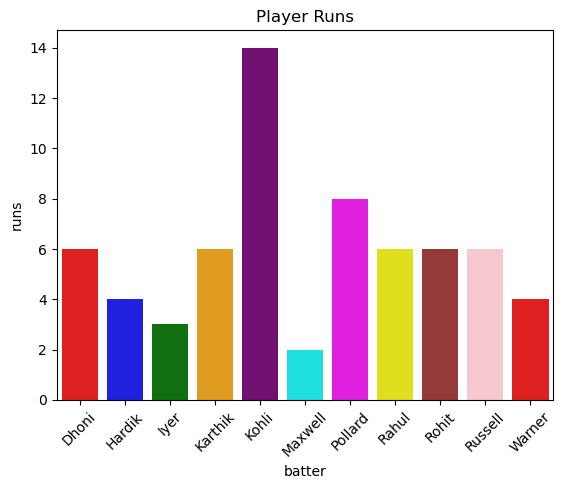

In [106]:
batsman_runs = runs.reset_index()
batsman_runs.columns = ["batter", "runs"]

colors = [
    "red","blue","green","orange","purple",
    "cyan","magenta","yellow","brown","pink"
]

sns.barplot(x="batter", y="runs", data=batsman_runs,
            palette=colors, hue='batter', legend=False)

plt.title("Player Runs")
plt.xticks(rotation=45)
plt.show()

In [101]:
batsman_runs

,batter,runs
0,Dhoni,6
1,Hardik,4
2,Iyer,3
3,Karthik,6
4,Kohli,14
5,Maxwell,2
6,Pollard,8
7,Rahul,6
8,Rohit,6
9,Russell,6


,team,wins
0,RCB,3
1,CSK,2
2,MI,2
3,GT,1
4,LSG,1
5,SRH,1
